#### Import libraries :

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib as plt
import scipy as sp 
print('done!')

#### Import dataset as DataFrame :

In [ ]:
df = pd.read_csv('dataset.csv')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/2014,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/2014,0,6,...,2,7,1,0,0,0,0,1,0,Spain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,3/7/2013,99,372,...,11,4,0,0,0,0,0,0,0,USA
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,3,8,0,0,0,0,0,0,0,Spain
2237,22,1976,Graduation,Divorced,46310.0,1,0,12/3/2012,99,185,...,5,8,0,0,0,0,0,0,0,Spain
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,10,3,0,0,0,0,0,0,0,India


#### checking the missing values :

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4    Income              2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntBakedProds        2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

As initial analysis reveals that the Income column contains 24 missing values. Moving forward, we have two primary options: deleting these rows or imputing the missing data using the median. Because the dataset is fully complete across all other columns, and we want to preserve that valuable customer data for our analysis, filling the missing income values with the median represents the most appropriate approach

note : we have detected as well that the label naming of Income has 2 white spaces one before and one after, removing them would make the process easier

In [ ]:
#renaming the column income to remove the white spaces :
df.rename(columns = {" Income " : "Income"}, inplace = True)

# filling the missing values
df["Income"]= df["Income"].fillna(df['Income'].median())
df["Income"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2240 entries, 0 to 2239
Series name: Income
Non-Null Count  Dtype  
--------------  -----  
2240 non-null   float64
dtypes: float64(1)
memory usage: 17.6 KB


#### checking duplicated rows 

In [ ]:
df.duplicated().sum()

np.int64(0)

there is no duplicated rows 

#### continuous vs discrete:

In [ ]:
discrete_variables = []
continuous_variables = []
for variable in df.columns :
    if df[variable].dtype == 'int64' or df[variable].dtype == 'object' or (df[variable].dropna() % 1 == 0).all()  :
             discrete_variables.append(variable)
    elif (df[variable].dropna() % 1 != 0).any() :
             continuous_variables.append(variable)
    else:
        print(variable,"is unknown")

print("Discrete:", discrete_variables)
print("Continuous:", continuous_variables)

Discrete: ['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntBakedProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Country']
Continuous: []


In [ ]:
fractional = df[df['Income'].notna() & (df[' Income '] % 1 != 0)]
print("\nHere are a few examples of values that do not end with a .0 suffix:")
fractional.head() 


Here are a few examples of values that do not end with a .0 suffix:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country


AttributeError: module 'matplotlib' has no attribute 'show'

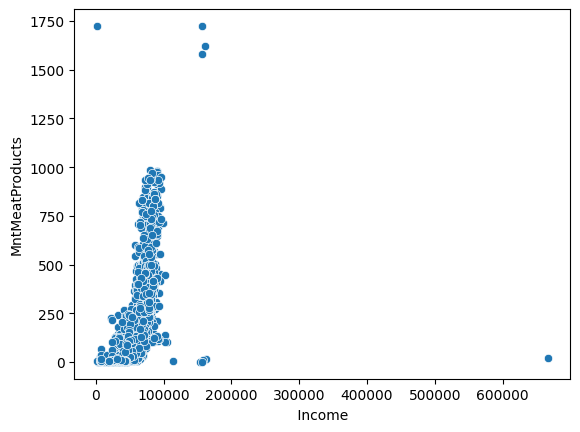

In [ ]:
sns.scatterplot(data=df,
                x=" Income ",
                y= 'MntMeatProducts')
plt.show()          